In [1]:
# Data preprocessing  
#importing the libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
f = pd.ExcelFile('wgm2018-dataset-crosstabs-all-countries.xlsx')
df = f.parse('Full dataset', na_values=[' '])

In [3]:
shp = df[["Q11A", "Age", "Gender", "Education","Urban_Rural", "WBI","Subjective_Income","EMP_2010"]]

In [4]:
shp = shp.rename(columns={"Q11A": "Interpersonal_trust"})

In [5]:
shp.describe(include='all')

,Interpersonal_trust,Age,Gender,Education,Urban_Rural,WBI,Subjective_Income,EMP_2010
count,149014.000000,149008.000000,149014.000000,148258.000000,148701.000000,148014.000000,146039.000000,149012.000000
mean,4.534909,42.242457,1.532386,1.863960,1.409661,2.712824,2.183335,3.682073
std,15.444020,18.345402,0.498952,0.686049,0.491773,1.073389,0.749539,2.117219
min,1.000000,15.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,27.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000
50%,2.000000,39.000000,2.000000,2.000000,1.000000,3.000000,2.000000,4.000000
75%,3.000000,56.000000,2.000000,2.000000,2.000000,4.000000,3.000000,6.000000
max,99.000000,100.000000,2.000000,3.000000,2.000000,4.000000,3.000000,6.000000


In [6]:
#from pandasgui import show

In [7]:
#show(shp)

In [5]:
d2=shp.dropna()
d2 = d2[d2["Interpersonal_trust"] <97]
d2 = d2[d2["Age"] <100]

<AxesSubplot:ylabel='Frequency'>

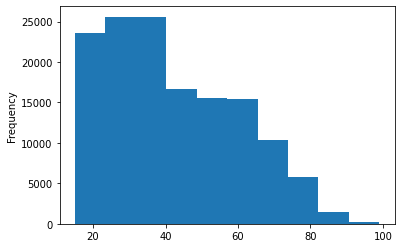

In [9]:
# Age distribution
d2['Age'].plot(kind = 'hist')

<AxesSubplot:>

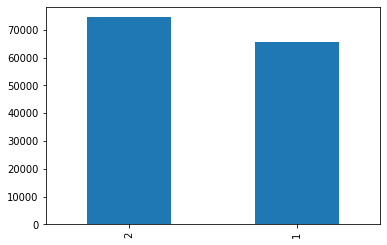

In [10]:
#Gender distribution
distribution = d2['Gender'].value_counts()
distribution.plot(kind='bar')

<AxesSubplot:>

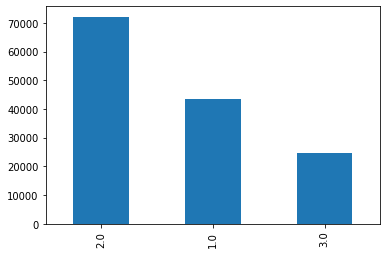

In [11]:
#Education distribution
distribution = d2['Education'].value_counts()
distribution.plot(kind='bar')

<AxesSubplot:>

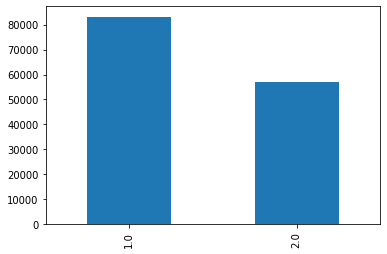

In [12]:
#Urban_Rural distribution
distribution = d2['Urban_Rural'].value_counts()
distribution.plot(kind='bar')

<AxesSubplot:>

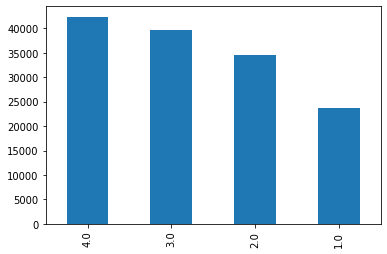

In [14]:
#WBI distribution
distribution = d2['WBI'].value_counts()
distribution.plot(kind='bar')

<AxesSubplot:>

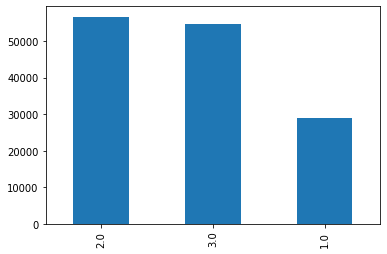

In [15]:
#Subjective_Income
distribution = d2['Subjective_Income'].value_counts()
distribution.plot(kind='bar')

<AxesSubplot:>

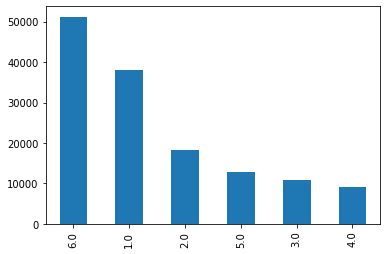

In [16]:
#Employment_status
distribution = d2['EMP_2010'].value_counts()
distribution.plot(kind='bar')

<AxesSubplot:>

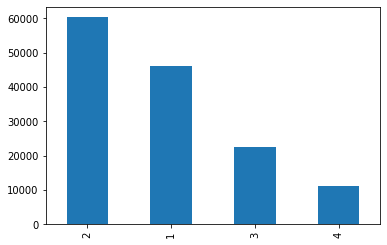

In [17]:
#Interpersonal_trust-
distribution = d2['Interpersonal_trust'].value_counts()
distribution.plot(kind='bar')

In [18]:
d2.describe()

,Interpersonal_trust,Age,Gender,Education,Urban_Rural,WBI,Subjective_Income,EMP_2010
count,140209.000000,140209.000000,140209.000000,140209.000000,140209.000000,140209.000000,140209.000000,140209.000000
mean,1.992447,41.989851,1.531107,1.865444,1.406807,2.717144,2.184004,3.668024
std,0.901166,17.903292,0.499033,0.683762,0.491240,1.070770,0.749614,2.118336
min,1.000000,15.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,27.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000
50%,2.000000,39.000000,2.000000,2.000000,1.000000,3.000000,2.000000,4.000000
75%,2.000000,55.000000,2.000000,2.000000,2.000000,4.000000,3.000000,6.000000
max,4.000000,99.000000,2.000000,3.000000,2.000000,4.000000,3.000000,6.000000


In [19]:
# Cheking correlations
d2.corr()

,Interpersonal_trust,Age,Gender,Education,Urban_Rural,WBI,Subjective_Income,EMP_2010
Interpersonal_trust,1.000000,-0.135346,0.037150,-0.019799,0.069726,-0.082233,0.136419,-0.001351
Age,-0.135346,1.000000,0.016979,-0.050041,0.002850,0.286694,-0.029199,0.149994
Gender,0.037150,0.016979,1.000000,-0.045758,0.007614,0.015953,0.027149,0.209409
Education,-0.019799,-0.050041,-0.045758,1.000000,0.213142,0.349600,-0.285921,-0.198836
Urban_Rural,0.069726,0.002850,0.007614,0.213142,1.000000,0.195465,-0.103180,-0.043562
WBI,-0.082233,0.286694,0.015953,0.349600,0.195465,1.000000,-0.293154,-0.091363
Subjective_Income,0.136419,-0.029199,0.027149,-0.285921,-0.103180,-0.293154,1.000000,0.092120
EMP_2010,-0.001351,0.149994,0.209409,-0.198836,-0.043562,-0.091363,0.092120,1.000000


In [42]:
#from pandas.plotting import scatter_matrix
#scatter_matrix(df, alpha=0.2, figsize=(10, 10))
#plt.show()

In [20]:
# Fitting Multiple Linear Regression to the Training set
#Splitting the dataset into the Training set and Test set
X = d2[[c for c in d2.columns if c != "Interpersonal_trust"]]
y = d2["Interpersonal_trust"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [21]:
from sklearn.linear_model import LinearRegression
sr = LinearRegression(normalize=True).fit(X_train, y_train, )

In [22]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler().fit(X_train)
X_train = sc_X.transform(X_train)
X_test = sc_X.transform(X_test)

In [23]:
# Getting parameters
sr.coef_, sr.intercept_

(array([-0.0062093 ,  0.06230122,  0.00406135,  0.16012872, -0.02353809,
         0.16052401,  0.0006182 ]),
 1.6358276634874371)

In [24]:
#Predict on train set
y_pred = sr.predict(X_train)
y_pred

array([1.75630805, 1.75081609, 1.98392857, ..., 1.39978374, 1.72300895,
       1.78252192])

In [25]:
#Score
sr.score(X_train, y_train), sr.score(X_test, y_test)

(-0.13672905215883802, -0.13309137682566474)

In [26]:
# Predicting the Test set results
y_pred1 = sr.predict(X_test)

In [27]:
# Mean squared error
from sklearn.metrics import mean_squared_error
mean_squared_error(y_train, sr.predict(X_train)), mean_squared_error(y_test, y_pred1)

(0.9201220262459548, 0.93217701228462)

In [28]:
# p-values
import statsmodels.api as sm
X = sm.add_constant(X_train)
mr1 = sm.OLS(y_train, X).fit()
mr1.pvalues
mr1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     Interpersonal_trust   R-squared:                       0.045
Model:                             OLS   Adj. R-squared:                  0.045
Method:                  Least Squares   F-statistic:                     747.4
Date:                 Sun, 20 Dec 2020   Prob (F-statistic):               0.00
Time:                         17:28:22   Log-Likelihood:            -1.4474e+05
No. Observations:               112167   AIC:                         2.895e+05
Df Residuals:                   112159   BIC:                         2.896e+05
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9922      0.003    758.691      0.000       1.987       1.997
x1            -0.1112      0.003    -39.429      0.000      -0.117      -0.106
x2             0.0311      0.003     11.558      0.000       0.026       0.036
x3             0.0028      0.003      0.937      0.349      -0.003       0.009
x4             0.0787      0.003     28.990      0.000       0.073       0.084
x5            -0.0252      0.003     -8.204      0.000      -0.031      -0.019
x6             0.1203      0.003     42.835      0.000       0.115       0.126
x7             0.0013      0.003      0.471      0.637      -0.004       0.007
==============================================================================
Omnibus:                     6608.578   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7688.621
Skew:                           0.632   Prob(JB):                         0.00
Kurtosis:                       2.779   Cond. No.                         1.89
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
# Backward Elimination with p-values
import statsmodels.api as sm
def backwardElimination(x, sl):
    numVars = len(x[0])
    for i in range(0, numVars):
        regressor_OLS = sm.OLS(y, x).fit()
        maxVar = max(regressor_OLS.pvalues)
        if maxVar > sl:
            for j in range(0, numVars - i):
                if (regressor_OLS.pvalues[j]) == maxVar:
                    x = np.delete(x, j, 1)
    regressor_OLS.summary()
    return x
         
SL = 0.05
X_opt = X_train[:, [0, 1, 2, 3, 4, 5,6]]
y = y_train
X_Modeled = backwardElimination(X_opt, SL)

In [33]:
# Fitting Optimized Multiple Linear Regression to the Training set
from sklearn.linear_model import LinearRegression
omr = LinearRegression().fit(X_train[:, 0:6], y_train)

In [34]:
# Getting parameters
omr.coef_, omr.intercept_

(array([-0.11100185,  0.03135418,  0.00258423,  0.07868353, -0.02529264,
         0.12035779]),
 1.9922437080424724)

In [36]:
# Predicting the Test set results
y_pred = omr.predict(X_test[:, 0:6])

In [38]:
# Coefficient of determination R^2
omr.score(X_train[:, 0:6], y_train), omr.score(X_test[:, 0:6], y_test)

(0.044565136879691436, 0.04528507519251901)

In [39]:
# Mean squared error
from sklearn.metrics import mean_squared_error
mean_squared_error(y_train, omr.predict(X_train[:, 0:6])), mean_squared_error(y_test, y_pred)

(0.7733739720390674, 0.7854294228977275)

In [6]:
# K-Means Clustering

In [6]:
# Feature Scaling
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler().fit(d2)
d2 = sc.transform(d2)
pd.DataFrame(d2, columns = ['Interpersonal_trust','Age', 'Gender', 'Education','Urban_Rural', 'WBI','Subjective_Income','EMP_2010']).round(2)

,Interpersonal_trust,Age,Gender,Education,Urban_Rural,WBI,Subjective_Income,EMP_2010
0,0.33,0.68,1.0,1.0,0.0,1.00,0.5,1.0
1,0.33,0.68,0.0,0.5,1.0,1.00,0.0,1.0
2,0.67,0.83,0.0,0.5,0.0,1.00,1.0,1.0
3,0.33,0.46,0.0,1.0,1.0,1.00,0.0,0.0
4,0.67,0.06,0.0,0.5,1.0,1.00,0.0,1.0
...,...,...,...,...,...,...,...,...
140204,0.00,0.11,0.0,1.0,0.0,0.33,0.0,1.0
140205,0.33,0.51,0.0,0.5,0.0,0.33,0.5,0.2
140206,0.00,0.20,1.0,0.5,0.0,0.33,1.0,1.0
140207,0.33,0.07,1.0,0.5,0.0,0.33,0.5,1.0


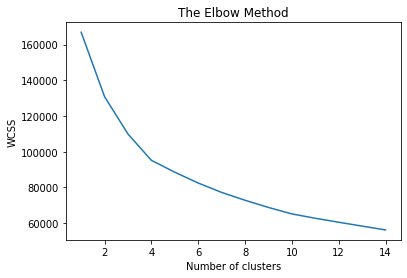

In [8]:
# Using the elbow method to find the optimal number of clusters
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 15):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 0)
    kmeans.fit(d2)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 15), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [9]:
# Using the silhouette method to find the optimal number of clusters
from sklearn.metrics import silhouette_score

sil = []

for k in range(2, 15):
  kmeans = KMeans(n_clusters = k).fit(d2)  
  preds = kmeans.fit_predict(d2)
  sil.append(silhouette_score(d2, preds, metric = 'euclidean'))


plt.plot(range(2, 15), sil)
plt.title('Silhouette Method')
plt.xlabel('Number of clusters')
plt.ylabel('Sil')
plt.show()

for i in range(len(sil)):
 print(str(i+2) +":"+ str(sil[i]))

KeyboardInterrupt: 

In [40]:
# Exporting the dataset
d2.to_csv('WelcomeGlobalMonitore_prep.csv', sep=';', index=False)